## Simple Linear Regression using numeric data

In [79]:
def estimate_coeff(x,y):
    #number of observations
    n = np.size(x)

    #mean of x and y vector
    m_x = np.mean(x)
    m_y = np.mean(y)

    #calculating cross-deviation
    SS_xy = np.sum(x*y) - n*m_x*m_y

    #calculating deviation about x
    SS_xx = np.sum(x*x) - n*m_x*m_x

    #calculating regression coefficients using least squares method
    b_1 = SS_xy / SS_xx
    b_0 = m_y - b_1*m_x

    return [b_0,b_1]

In [80]:
def plot_regression_line(x, y,b):
    #plotting the actual data points
    plt.scatter(x,y, color="green", marker ='o', s=30)

    #predicted response vector
    y_pred = b[0] + b[1] * x

    #plotting the regression line
    plt.plot(x,y_pred, color="red")

    #putting labels
    plt.xlabel("x")
    plt.ylabel("y")

Regression Coefficients:
 b_0:1.2363636363636363
b_1:1.1696969696969697


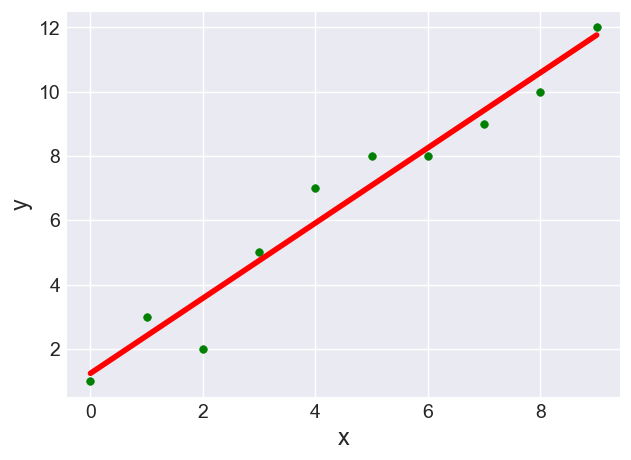

In [81]:
def main():
    x = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
    y = np.array([1, 3, 2, 5, 7, 8, 8, 9, 10, 12])
    b = estimate_coeff(x,y)
    print(f"Regression Coefficients:\n b_0:{b[0]}\nb_1:{b[1]}")
    plot_regression_line(x,y,b)
    plt.show()

if __name__ == "__main__":
    main()

## Multilple Linear Regression Using the Boston Housing dataset

In [82]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn import linear_model
import pandas as pd


In [83]:
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+",skiprows=22, header=None)
raw_df.head()

,0,1,2,3,4,5,6,7,8,9,10
0,0.00632,18.00,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3
1,396.90000,4.98,24.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.02731,0.00,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8
3,396.90000,9.14,21.60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.02729,0.00,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8


In [84]:
X = np.hstack([raw_df.values[::2, :],raw_df.values[1::2, :2]])
Y = raw_df.values[1::2,2]

In [85]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.4,random_state=1)

In [86]:
reg = linear_model.LinearRegression()
reg.fit(X_train, Y_train)

LinearRegression()

In [87]:
print("Coefficients:",reg.coef_)

print("Variance Score:{}".format(reg.score(X_test,Y_test)))

Coefficients: [-7.95572889e-02  7.11808367e-02  5.82382970e-02  1.48237233e+00
 -1.67360287e+01  2.95000985e+00  2.33290549e-02 -1.35721280e+00
  3.13822151e-01 -1.16929875e-02 -8.07436236e-01  6.67075368e-03
 -6.71019667e-01]
Variance Score:0.7325323805669568


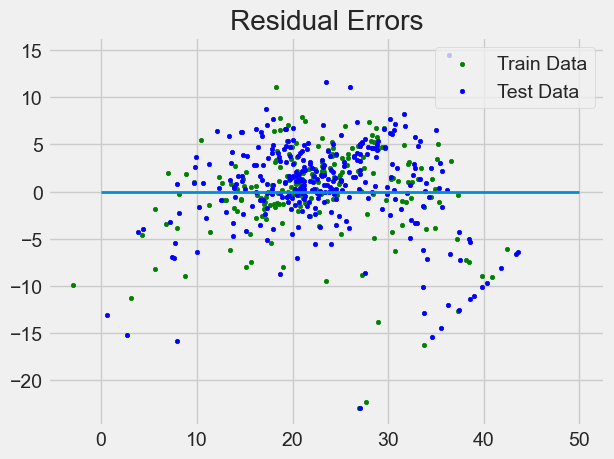

In [88]:
# plot for residual error
#Setting the plot style
plt.style.use("fivethirtyeight")

#plotting residual errors in training data
plt.scatter(reg.predict(X_train),
            reg.predict(X_train)-Y_train,
            color="green",
            s=10,
            label="Train Data")

#plotting residual errors in testing data
plt.scatter(reg.predict(X_test),
            reg.predict(X_test)-Y_test,
            color="blue",
            s=10,
            label="Test Data")

#plotting line for zero residual error
plt.hlines(y=0, xmin=0, xmax=50, linewidth=2)

#plotting legend
plt.legend(loc='upper right')

#plot title
plt.title("Residual Errors")

#method call for showing the plt
plt.show()

Polynomial Regression

Study of curvilinear relationship between poistion and salary

In [89]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

df = pd.read_csv("../data/raw/Position_Salaries.csv")
df


,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


In [90]:
X = df.iloc[:,1:2].values
X

array([[ 1],
       [ 2],
       [ 3],
       [ 4],
       [ 5],
       [ 6],
       [ 7],
       [ 8],
       [ 9],
       [10]], dtype=int64)

In [91]:
Y = df.iloc[:,2].values
Y

array([  45000,   50000,   60000,   80000,  110000,  150000,  200000,
        300000,  500000, 1000000], dtype=int64)

In [92]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X,Y)


LinearRegression()

In [93]:
from sklearn.preprocessing import PolynomialFeatures
poly_reg2 = PolynomialFeatures(degree=2)
X_poly2 = poly_reg2.fit_transform(X)
lin_reg2 = LinearRegression()
lin_reg2.fit(X_poly2,Y)

poly_reg3 = PolynomialFeatures(degree=3)
X_poly3 = poly_reg3.fit_transform(X)
lin_reg3 = LinearRegression()
lin_reg3.fit(X_poly3,Y)

poly_reg4 = PolynomialFeatures(degree=4)
X_poly4 = poly_reg4.fit_transform(X)
lin_reg4 = LinearRegression()
lin_reg4.fit(X_poly4,Y)

LinearRegression()

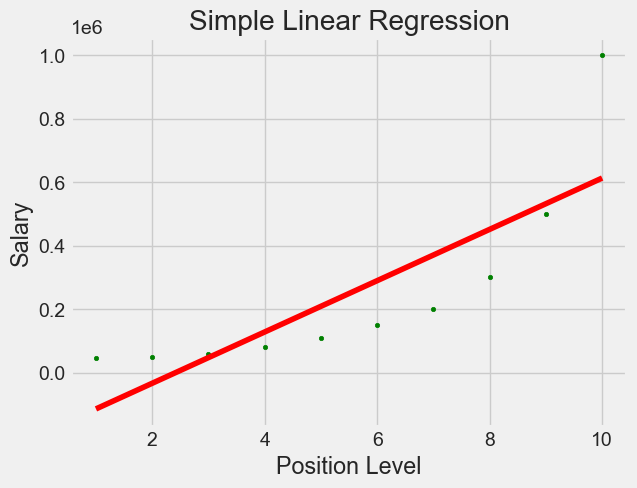

In [94]:
plt.scatter(X,Y,
            color="green",
            s=10)
plt.title("Simple Linear Regression")
plt.plot(X, lin_reg.predict(X), color="red")
plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.show()

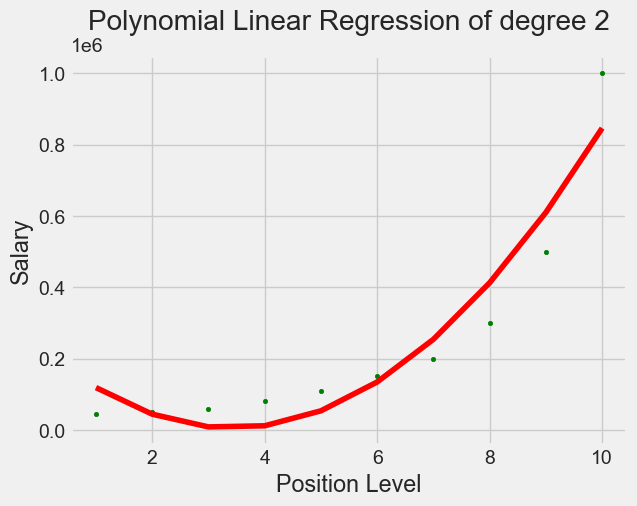

In [95]:
plt.scatter(X,Y,
            color="green",
            s=10)
plt.title("Polynomial Linear Regression of degree 2")

plt.plot(X,lin_reg2.predict(X_poly2), color="red")
plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.show()

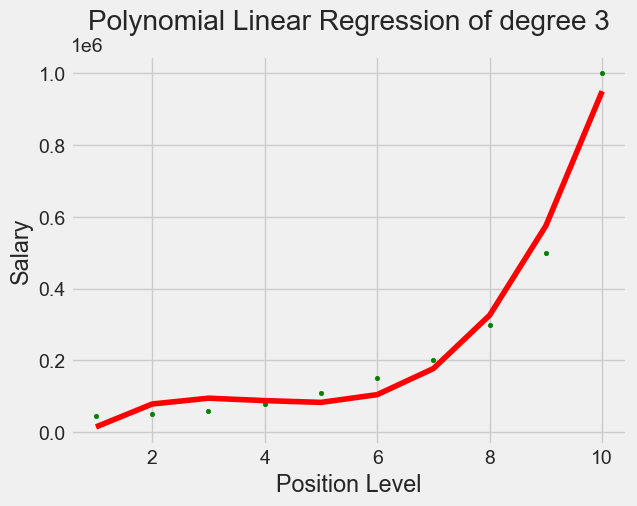

In [96]:
plt.scatter(X,Y,
            color="green",
            s=10)
plt.title("Polynomial Linear Regression of degree 3")

plt.plot(X,lin_reg3.predict(X_poly3), color="red")
plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.show()

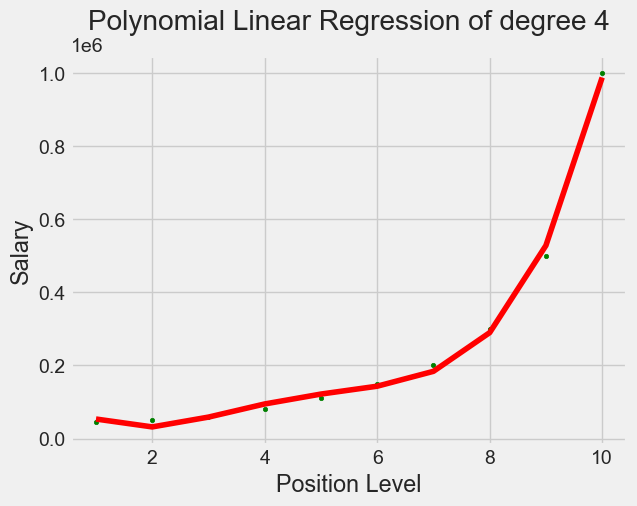

In [97]:
plt.scatter(X,Y,
            color="green",
            s=10)
plt.title("Polynomial Linear Regression of degree 4")

plt.plot(X,lin_reg4.predict(X_poly4), color="red")
plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.show()

##  Understanding the curvilinear relationship between temperature and atmospheric pressure

In [98]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("../data/raw/data.csv")
df.head()

,sno,Temperature,Pressure
0,1,0,0.0002
1,2,20,0.0012
2,3,40,0.0060
3,4,60,0.0300
4,5,80,0.0900


In [99]:
df

,sno,Temperature,Pressure
0,1,0,0.0002
1,2,20,0.0012
2,3,40,0.0060
3,4,60,0.0300
4,5,80,0.0900
5,6,100,0.2700


In [100]:
X = df.iloc[::, 1:2].values
X

array([[  0],
       [ 20],
       [ 40],
       [ 60],
       [ 80],
       [100]], dtype=int64)

In [101]:
Y = df.iloc[::,2].values
Y

array([2.0e-04, 1.2e-03, 6.0e-03, 3.0e-02, 9.0e-02, 2.7e-01])

In [102]:
#fitting linear regression to the dataset
from sklearn.linear_model import LinearRegression
lin = LinearRegression()

lin.fit(X,Y)

LinearRegression()

In [103]:
#fitting Polynomial regression to the dataset
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=4)
X_poly = poly.fit_transform(X)
lin2 = LinearRegression()
lin2.fit(X_poly,Y)

LinearRegression()

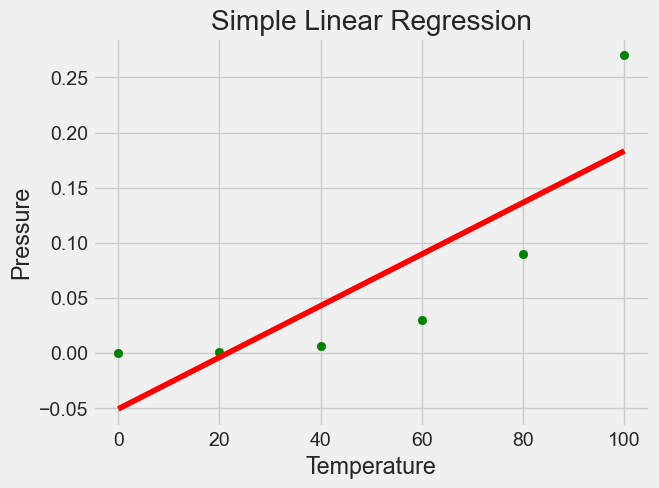

In [104]:
#Visualizing the linear regression results
plt.scatter(X, Y, color = "green")
plt.plot(X,lin.predict(X), color = "Red")
plt.title("Simple Linear Regression")
plt.xlabel("Temperature")
plt.ylabel("Pressure")
plt.show()

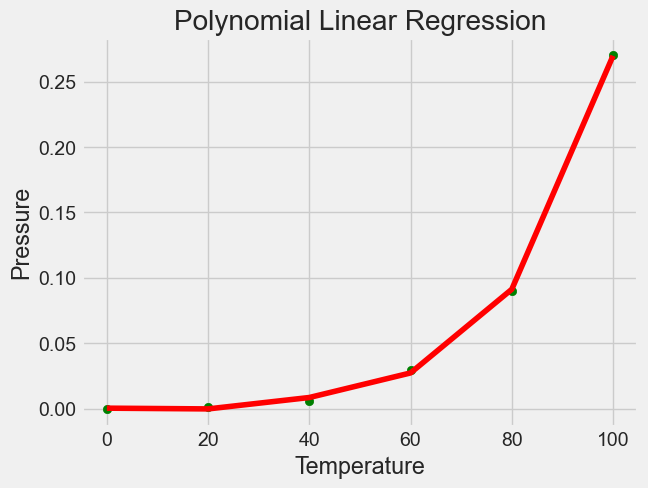

In [105]:
#Visualizing the polynomial regression results
plt.scatter(X,Y, color="green")
plt.plot(X,lin2.predict(X_poly), color="red")
plt.title("Polynomial Linear Regression")
plt.xlabel("Temperature")
plt.ylabel("Pressure")
plt.show()

In [106]:
#Predicting for some more values
results_array = np.empty((0, 3))
results_array = np.vstack((results_array,["Temperature","O/p with Simple Linear Regression","O/p with Polynomial Linear"]))


temp_val=10
predarray = np.array([[temp_val]])
results_array = np.vstack((results_array,[
    str(temp_val),
    round(lin.predict(predarray)[0],2),
    round(lin2.predict(poly.fit_transform(predarray))[0],2)]
))



temp_val=50
predarray = np.array([[temp_val]])
results_array = np.vstack((results_array,[
    str(temp_val),
    round(lin.predict(predarray)[0],2),
    round(lin2.predict(poly.fit_transform(predarray))[0],2)]
))

temp_val=90
predarray = np.array([[temp_val]])
results_array = np.vstack((results_array,[
    str(temp_val),
    round(lin.predict(predarray)[0],2),
    round(lin2.predict(poly.fit_transform(predarray))[0],2)]
))

print("The Predicted values for 10, 50 and 90 using simple linear and polynomial regression are as follows:")
results_array

The Predicted values for 10, 50 and 90 using simple linear and polynomial regression are as follows:


array([['Temperature', 'O/p with Simple Linear Regression',
        'O/p with Polynomial Linear'],
       ['10', '-0.03', '-0.0'],
       ['50', '0.07', '0.02'],
       ['90', '0.16', '0.16']], dtype='<U33')

In [107]:
#formatting the dataframe for better visualization
df_new = pd.DataFrame(X, columns=["Temperature"])
df_new["Pressure"] = Y
results_array_df = pd.DataFrame(results_array[1::,0:2], columns=["Temperature","Pressure"])
df_new = pd.concat([results_array_df,df_new], axis=0)
df_new.rename(columns={'Pressure': 'Simple linear Regression'}, inplace=True)
print(df_new)

df_2 = pd.DataFrame(X, columns=["Temperature"])
df_2["Pressure"] = lin2.predict(X_poly).astype(float).round(2)
results_array_df = pd.DataFrame(results_array[1::,0:3:2], columns=["Temperature","Pressure"])
df_2 = pd.concat([results_array_df,df_2], axis=0)
df_2.rename(columns={'Pressure': 'Polynomial Regression'}, inplace=True)
df_2 = pd.merge(df_2, df_new, on="Temperature", how="outer")
df_2["Temperature"] = pd.to_numeric(df_2["Temperature"])
df_2 = df_2.sort_values(by="Temperature")
print(df_2)




  Temperature Simple linear Regression
0          10                    -0.03
1          50                     0.07
2          90                     0.16
0           0                   0.0002
1          20                   0.0012
2          40                    0.006
3          60                     0.03
4          80                     0.09
5         100                     0.27
   Temperature Polynomial Regression Simple linear Regression
0            0                   0.0                   0.0002
6           10                  -0.0                    -0.03
1           20                  -0.0                   0.0012
2           40                  0.01                    0.006
7           50                  0.02                     0.07
3           60                  0.03                     0.03
4           80                  0.09                     0.09
8           90                  0.16                     0.16
5          100                  0.27                

Using both Linear Regression and Polynomial Regression models, predict the pressure
values when the temperature is 10, 50, and 90.
 Compare the predicted values from both models.
 Discussion Question: Which model performs better and why? Provide a brief explanation
based on your observations.

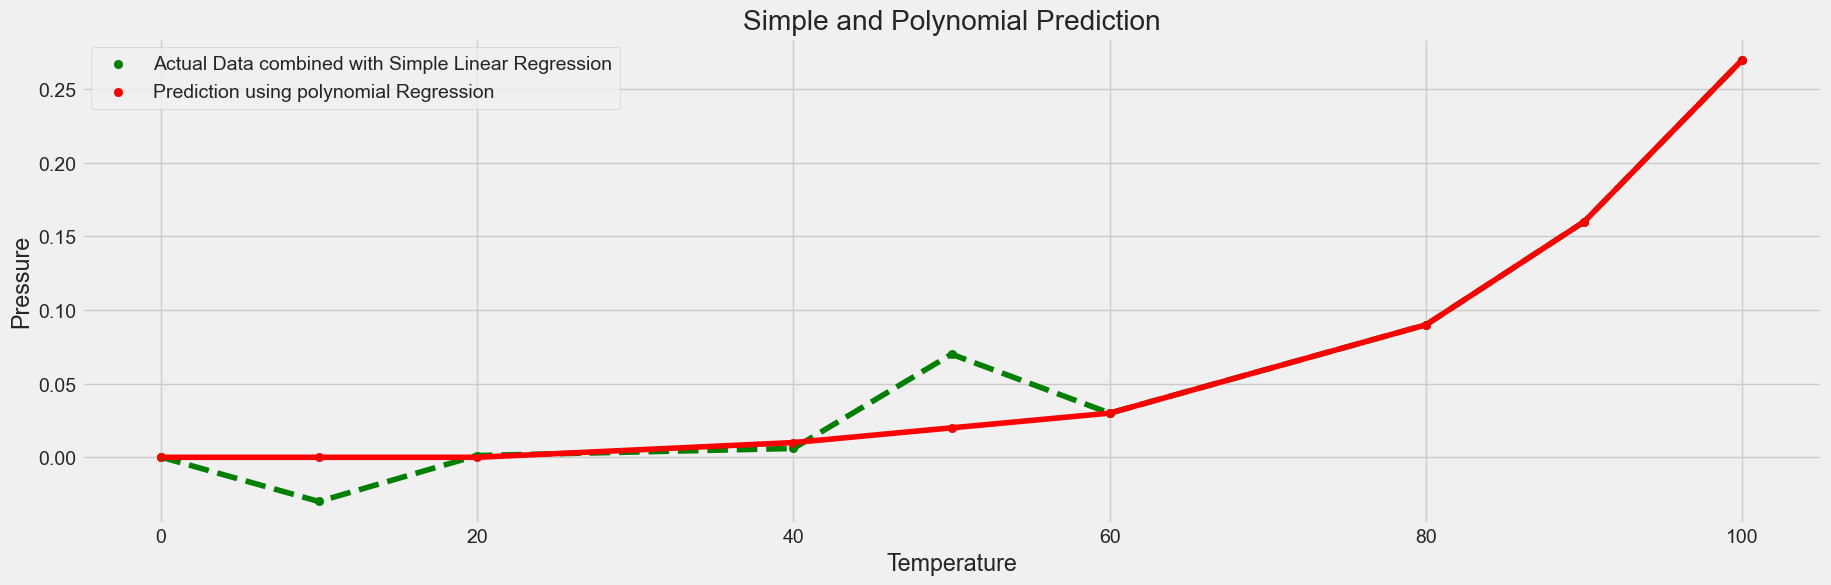

In [108]:
#Visualizing the polynomial regression results
plt.figure(figsize=(20, 6))
plt.scatter(df_2["Temperature"],df_2["Simple linear Regression"], color="green", label="Actual Data combined with Simple Linear Regression")
plt.plot(df_2["Temperature"], df_2["Simple linear Regression"], color="green", linestyle='--')
plt.scatter(df_2["Temperature"],df_2["Polynomial Regression"],color = "red" ,label="Prediction using polynomial Regression")
plt.plot(df_2["Temperature"], df_2["Polynomial Regression"], color="red", linestyle='-')
plt.title("Simple and Polynomial Prediction")
plt.xlabel("Temperature")
plt.ylabel("Pressure")
plt.legend()
plt.show()

## Observations:
1. When the temperature is 10, the linear model predicts -0.03, which doesn’t really make sense since pressure can’t be negative. On the other hand, the polynomial model gives a more reasonable value close to 0.
2. At temperature 50, the linear model predicts 0.07, while the polynomial model gives 0.02. The difference here suggests that the linear model might not be capturing the curve in the data as well.
3. For temperature 90, both models give similar results (0.16), meaning they agree at higher temperatures.

## Which Model performs better ?
The polynomial model does a better job because:

It follows the curve in the data rather than forcing a straight-line relationship.
The linear model gives a negative pressure value at T=10, which isn’t realistic.
The polynomial model aligns better with how the data behaves, making it a more accurate choice for this scenario.
So, if we want the most reliable predictions, polynomial regression is the way to go!

